### Análise exploratória
#### Este notebook serve para explorar e sintetizar as informações dos dados coletados.

In [ ]:
""" Importação das dependências para a análise """

from src.query_exploratoria import (
    tabela_completa,
    completude_dados,
    capitais_assiduas,
    soma_valores_deflacionados_pagas_por_ano,
    frequencia_categoria,
    soma_valores_por_etapas,
    funcoes_por_valor_ano,
)
from visualizacao.linha_deflacao import plotar_soma_valores_deflacionados_por_ano
from src.visualizacao.frequencia import plotar_frequencia_categoria
from src.config.ConexaoBanco import db
from src.config.grafico import configurar_graficos

configurar_graficos()

In [8]:
""" fechar conexção com o banco """
db.con.close()

In [2]:
""" sumário da base de dados """
tabela_completa(db.con).df().describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
instituicao,50334,26,Prefeitura Municipal do Rio de Janeiro - RJ,3003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cod_ibge,50334.0,NaN,NaN,NaN,2838185.54339,1155652.238554,1100205.0,2111300.0,2704302.0,3550308.0,5208707.0
uf,50334,26,RJ,3003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
populacao,50334.0,NaN,NaN,NaN,2194815.628422,2845665.737101,299127.0,612547.0,1115932.0,2392678.0,12396372.0
etapa_despesa,50334,5,Despesas Empenhadas,11495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conta,50334,176,Despesas Exceto Intraorçamentárias,696,NaN,NaN,NaN,NaN,NaN,NaN,NaN
identificador_conta,50334,1,siconfi-cor_TotalDespesas,50334,NaN,NaN,NaN,NaN,NaN,NaN,NaN
valor,50334.0,NaN,NaN,NaN,237174480.832626,1808001958.126338,-227951175.17,720909.8125,7848379.855,64403039.1225,112262084025.919998
ano_exercicio,50334.0,NaN,NaN,NaN,2022.277705,1.577111,2020.0,2021.0,2022.0,2024.0,2025.0
cod_funcao,42935,27,10,4443,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Completude
A completude dos dados refere-se a uma proporção de informações preenchidas de um total esperado. Abaixo está uma descrição da completude da base do finbra:

In [3]:
completude_dados(db.con).df()

,ano_exercicio,qtd_capitais
0,2020,26
1,2021,26
2,2022,26
3,2023,26
4,2024,26
5,2025,11


A base de dados contem os anos de 2020 há 2025, em todos os anos - exceto 2025 - todas as capitais declararam suas informações.
15 capitais em 2025 deixaram de declarar informações financeiras.

#### Quais Capitais que entregaram em todos os anos?
A tabela abaixo mostra quais das 26 capitais declararam informações em 2025, podendo ser utilizadas para análises longitudinais apenas dessas capitais, não inviabilizando esses dados.

In [3]:
capitais_assiduas(db.con).df()

,municipio,uf
0,Rio Branco,AC
1,Manaus,AM
2,Salvador,BA
3,Fortaleza,CE
4,Goiânia,GO
5,São Luís,MA
6,Belo Horizonte,MG
7,Belém,PA
8,Rio de Janeiro,RJ
9,Porto Velho,RO


#### Deflação dos Valores
Para análises financeiras em séries temporais (2020 a 2025), é necessário realizar a atualização dos valores para um ano-base, a fim de ajustar o impacto acumulado da inflação nos anos anteriores. Isso converte a base de nominal para real, garantindo uma comparação fidedigna do poder de compra ao longo do tempo.

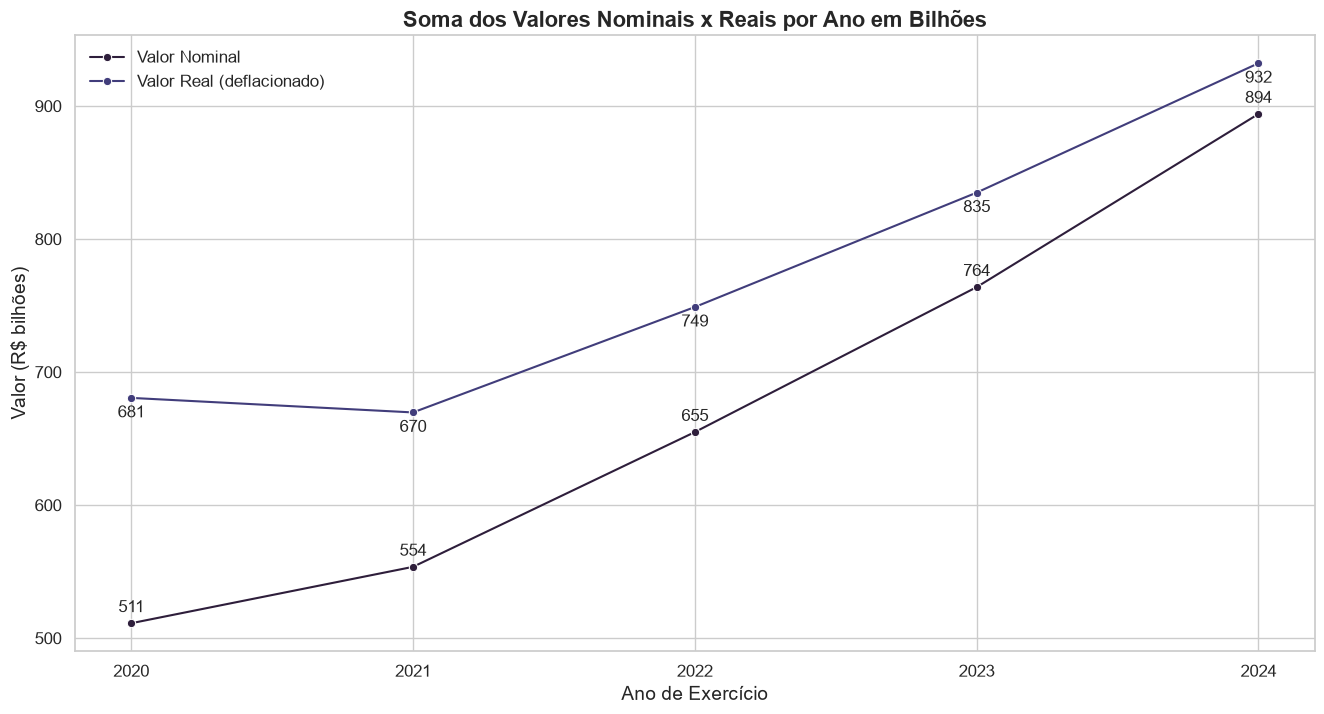

In [4]:
""" Calculado as despesas pagas, que saiu de caixa """
df = soma_valores_deflacionados_pagas_por_ano(db.con).df()
plotar_soma_valores_deflacionados_por_ano(df)

`Ilusão Nominal`: A linha do Valor Nominal dá a falsa impressão de que os gastos das capitais cresceram de forma contínua em todo o período.

`Realidade Real`: A correção inflacionária revela que entre 2020 e 2021, houve uma retração real de 11 bilhões de reais.

Isso mostra que avaliar séries temporais sem deflacionar os valores gera conclusões distorcidas sobre a evolução real dos gastos públicos.

#### Frequência das etapas das despesas

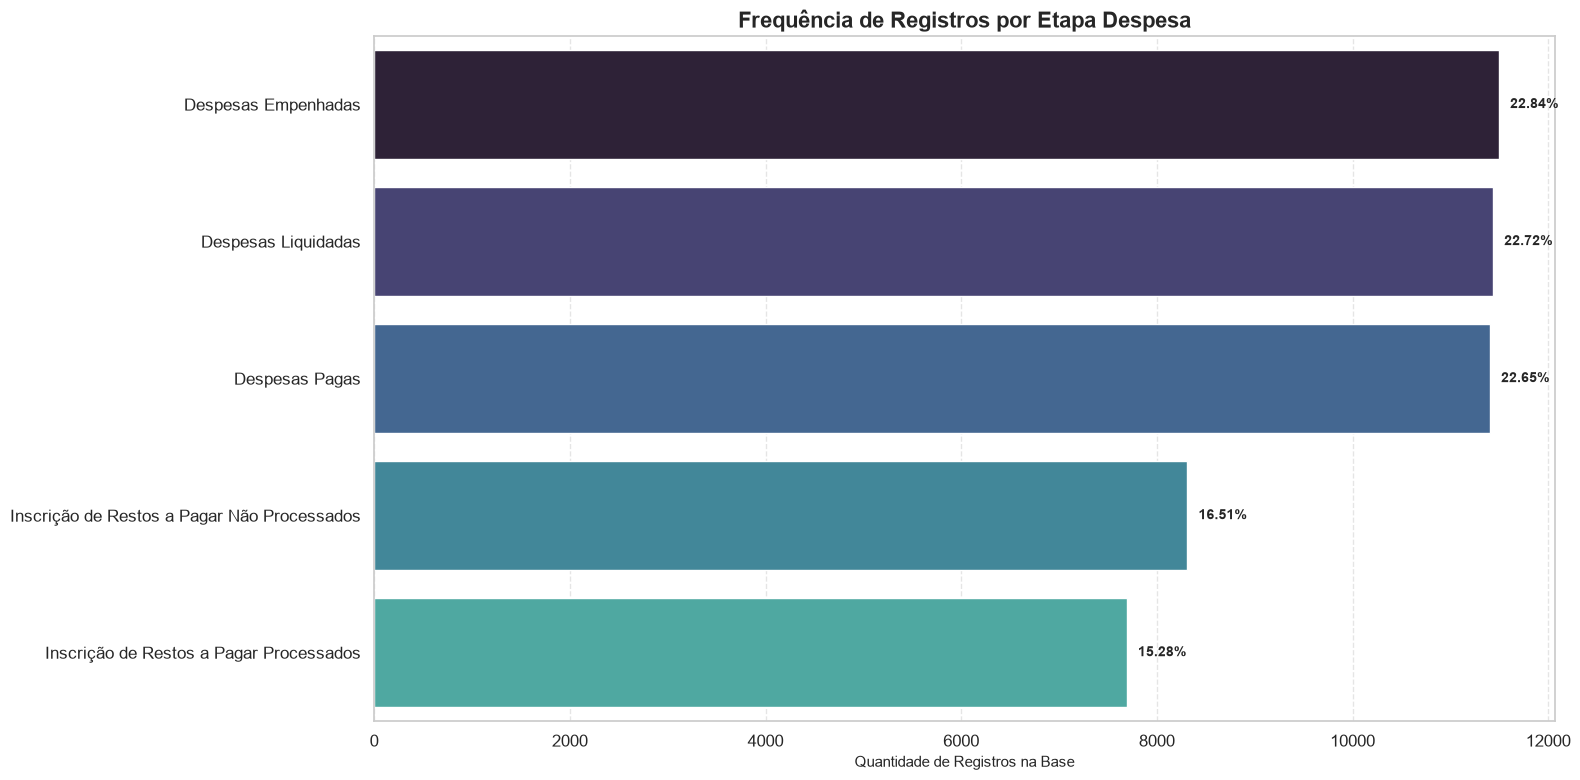

In [5]:
coluna = "etapa_despesa"
df = frequencia_categoria(db.con, coluna).df()
plotar_frequencia_categoria(df, coluna)

Isso mostra que os municípios brasileiros carregam um volume massivo de obrigações financeiras de um ano civil para o outro. Ao analisar a evolução dos gastos de uma cidade ao longo dos anos, ignorar ou misturar os Restos a Pagar pode distorcer a percepção de quão "saudáveis" estão as contas daquele ano específico.

#### Despesas per-capta por etapa de despesa
Abaixo encontra-se uma tabela da comparação entre as etapas das despesas e a soma dos valores totais e per-capta nos anos assiduos (2020 há 2024).

In [6]:
soma_valores_por_etapas(db.con).df()

,etapa_despesa,total_valor_real,total_valor_milhoes,despesa_per_capita
0,Despesas Empenhadas,4.215070e+12,4215070.20,189.45
1,Despesas Liquidadas,3.957744e+12,3957743.77,178.61
2,Despesas Pagas,3.866141e+12,3866141.03,174.81
3,Inscrição de Restos a Pagar Não Processados,2.530537e+11,253053.67,13.98
4,Inscrição de Restos a Pagar Processados,9.102593e+10,91025.93,5.44


Além de evidenciar as etapas sequenciais dos processos de contabilidade pública, esta tabela alerta que a falta de um filtro adequado pode fazer com que a mesma despesa seja somada múltiplas vezes (como ocorre ao aplicar um SUM(valor_real) na base inteira sem filtrar a coluna etapa_despesa). Da mesma forma, o gráfico também revela fortes indicativos de endividamentos de períodos anteriores.Existe uma eficiência em âmbito nacional das capitais; o fluxo da despesa per capita ocorre com pouca variação e de forma coerente:

$$\text{Empenhadas (R\$ 189,39)} \rightarrow \text{Liquidadas (R\$ 178,96)} \rightarrow \text{Pagas (R\$ 175,16)}$$

A diferença entre o que foi empenhado (planejado/reservado) e o que foi efetivamente pago é pequena.As despesas não processadas (empenhadas, mas com serviços não realizados) podem sinalizar contratos com temporalidade alta.O fato de as despesas processadas serem baixas reflete uma boa saúde financeira geral. No entanto, é sempre bom observar e destrinchar os dados para entender como os componentes individuais geram essa relação de boa saúde financeira.

##### TOP 3 principais funções com maiores gastos por valor per capta de 2020 à 2024


In [7]:
funcoes_por_valor_ano(db.con).df().head(3)

,cod_funcao,nome_funcao,total_valor_per_capta,media_valor_per_capta
0,09,Previdência Social,448.10,378.24
1,10,Saúde,387.75,362.26
2,12,Educação,320.79,345.09


Essa busca foi feita para decidir áreas específicas de análise mais direcionadas.

Previdência Social, Saúde e Educação, são áreas que possuem orçamento definido obrigatórios, e são importantes para análises macro.
Por outro lado, a Previdência Social são orçamentos engessados com despesas obrigatórias de transferência, sem muita variabilidade analítica sobre escolhas de gasto. Nesse sentido, para buscar sair desse campo mas focar também no importante geral e não apenas de serviços públicos parados, a Previdência social será substituída pela função `13 - Cultura`.

**Por que incluir 13 - Cultura?** É uma área que transita entre o serviço público e o fomento. Seu orçamento possui maior nível de discricionariedade (depende de projetos, leis de incentivo e decisões políticas sazonais). Estudar a Cultura nos permite entender como o orçamento se comporta fora do eixo das obrigações constitucionais rígidas.

Essa definição encerra nossa Análise Exploratória e estabelece a base para as perguntas descritivas formuladas no [notebook de análise descritiva](analise_descritiva.ipynb).